<a href="https://colab.research.google.com/github/J4SIB/ai-course-gp/blob/main/Kopia_notatnika_Klasyfikator_opinii_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Klasifikator opinii oparty na modelu BERT
1. Konfiguracja środowiska
2. Definicja kategorii i ustalenie ich reprezentacji wektorowych
3. Ręczna klasyfikacja + interface gradio
4. Klasyfikacja i analiza zbioru danych
5. Wykresy i prezentacja zbioru danych
6. Import zbioru danych wejściowych i generacja wyników



### 1. Konfiguracja środowiska

In [2]:
!pip install sentence-transformers matplotlib

In [3]:
from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import gradio as gr

model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### 2. Definicja kategorii i ustalenie ich reprezentacji wektorowych

In [21]:
# categories = {
#     "pozytywna": [
#         "To był świetny produkt.",
#         "Bardzo polecam, wszystko super.",
#         "Jestem zadowolony.",
#         "Naprawdę dobra jakość.",
#         "Gra była bardzo przyjemna.",
#         "Rewelacyjna rozgrywka i grafika.",
#         "Bardzo satysfakcjonująca mechanika gry.",
#         "Czułem dużo frajdy podczas grania."
#     ],
#     "negatywna": [
#         "Nie polecam, bardzo słaba jakość.",
#         "To była strata pieniędzy.",
#         "Jestem niezadowolony.",
#         "Znudziła mi się po jednym dniu.",
#         "Gra była nudna i frustrująca.",
#         "Rozgrywka była monotonna i męcząca.",
#         "Sterowanie działało bardzo źle.",
#         "Zawiodłem się całkowicie."
#     ]
# }

categories = {
    "pozytywna": [
        "To był świetny produkt.",
        "Bardzo polecam, wszystko super.",
        "Jestem zadowolony.",
        "Naprawdę dobra jakość.",
        "Gra była bardzo przyjemna.",
        "Rewelacyjna rozgrywka i grafika.",
        "Bardzo satysfakcjonująca mechanika gry.",
        "Czułem dużo frajdy podczas grania.",

        # Nowe pozytywne opinie:
        "Absolutnie genialna gra! Spędziłem w niej już ponad 30 godzin.",
        "Jedna z najlepszych gier, w jakie grałem w tym roku.",
        "Grafika wygląda obłędnie, a sterowanie jest intuicyjne.",
        "Historia wciąga od pierwszych minut.",
        "Super zbalansowana trudność – idealnie na relaks i wyzwanie.",
        "Muzyka i dźwięki są na najwyższym poziomie.",
        "Mnóstwo treści, nie można się nudzić.",
        "Rewelacyjny multiplayer, świetnie bawiłem się ze znajomymi.",
        "Postacie są świetnie napisane, polubiłem je od razu.",
        "Gra działa płynnie nawet na moim starszym sprzęcie.",
        "Każdy poziom to czysta przyjemność.",
        "To gra, do której na pewno wrócę wiele razy."
    ],
    "negatywna": [
        "Nie polecam, bardzo słaba jakość.",
        "To była strata pieniędzy.",
        "Jestem niezadowolony.",
        "Znudziła mi się po jednym dniu.",
        "Gra była nudna i frustrująca.",
        "Rozgrywka była monotonna i męcząca.",
        "Sterowanie działało bardzo źle.",
        "Zawiodłem się całkowicie.",

        # Nowe negatywne opinie:
        "Najgorsza gra, jaką kupiłem w ostatnim czasie.",
        "Bugi i crashe co chwilę – nie da się normalnie grać.",
        "Fabuła jest przewidywalna i banalna.",
        "Poziom trudności jest źle zbalansowany – albo za łatwa, albo niemożliwa.",
        "Grafika wygląda jak z poprzedniej generacji.",
        "Sterowanie jest opóźnione i nieprecyzyjne.",
        "Mikropłatności zniszczyły całą przyjemność z gry.",
        "AI przeciwników jest tragiczne – zachowują się jak idioci.",
        "Za krótka, przeszedłem ją w 4 godziny.",
        "Dźwięk jest fatalny, muzyka irytuje po 10 minutach.",
        "Nie ma sensu w tej grze – wszystko jest chaotyczne.",
        "Rozczarowanie totalne, szkoda każdej minuty spędzonej w tej grze."
    ]
}

# =================================
# MIEJSCE NA KOD
category_vectors = {}
for category, sentences in categories.items():
  embeddings = model.encode(sentences)
  category_vectors[category] = np.mean(embeddings, axis=0)
print(category_vectors)

{'pozytywna': array([ 7.33860657e-02, -6.97109327e-02, -8.20020959e-02, -6.67768121e-02,
       -2.34102130e-01, -6.61267480e-03,  2.00614780e-01,  1.06691383e-01,
        8.87365662e-04,  8.50485116e-02, -2.66363267e-02, -5.37378676e-02,
        5.07059619e-02,  9.23572183e-02, -8.08669776e-02,  1.34242270e-02,
        2.25747660e-01,  1.00425631e-02, -8.21587592e-02, -1.03158318e-01,
       -2.23865181e-01,  3.65211442e-02, -6.88982457e-02,  6.27843887e-02,
       -4.23267037e-02,  2.94879191e-02, -1.15990832e-01,  2.59288885e-02,
       -9.07472000e-02, -1.46771103e-01,  1.28965476e-03, -2.21692324e-02,
        1.77767962e-01, -5.27196843e-03, -2.38344118e-01,  1.69203892e-01,
       -1.30115315e-01, -1.88787989e-02, -3.19468719e-03, -1.44279480e-01,
       -2.27201097e-02,  1.10625729e-01,  1.13698818e-01,  1.47920430e-01,
        5.16206548e-02,  5.09576723e-02, -3.64507847e-02, -4.55781035e-02,
        1.71930894e-01,  1.37379721e-01,  5.20721972e-02,  1.04949940e-02,
       -1.9

### 3. Ocena ręcznie wpisanej opinii + gradio

In [22]:
# =================================
# miejsce na funkcję classify_opinion
def classify_opinion(opinion):
  embedding = model.encode([opinion])[0]
  similarities = {category: cosine_similarity([embedding], [vector])[0][0] for category, vector in category_vectors.items()}
  return similarities


In [23]:
# =================================
# miejsce na gradio
gr.Interface(
    fn=classify_opinion,
    inputs = gr.Textbox(label="Wpisz Opinię"),
    outputs = gr.Label(label="Wynik klasyfikacji"),
    title="Klasyfikator opinii",
    description="Wpisz opinię o grze lub produkcie, a model oceni, czy jest pozytywna czy negatywna."
).launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9a3fc71eb3aca71757.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### 4. Klasyfikacja i analiza zbioru danych

In [24]:
# =================================
# miejsce na funkcję load_opinions
def load_opinions(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        return [line.strip() for line in f if line.strip()]

# =================================
# miejsce na funkcję classify_opinion_vector
def classify_opinion_vector(opinion):
  embedding = model.encode([opinion])[0]
  similarities = {category: cosine_similarity([embedding], [vector])[0][0] for category, vector in category_vectors.items()}
  predicted_class = max(similarities,key=similarities.get)
  return predicted_class, similarities
# =================================
# miejsce na funkcję analyze_opinions
def analyze_opinions(file_path):
  opinions = load_opinions(file_path)
  results = {"pozytywna": 0, "negatywna": 0}
  all_info = []
  for opinion in opinions:
    predicted_class, similarities = classify_opinion_vector(opinion)
    results[predicted_class] += 1
    all_info.append((opinion, predicted_class, similarities))
  return results, all_info

### 5. Wykresy i prezentacja zbioru danych

In [25]:
def show_results(results):
    labels = list(results.keys())
    counts = list(results.values())
    total = sum(counts)
    percentages = [100 * c / total for c in counts]
    plt.bar(labels, percentages, color=["green", "red"])
    plt.title("Procent opinii w każdej kategorii")
    plt.ylabel("Procent")
    plt.ylim(0, 100)
    plt.show()

def show_detailed_results(details):
    for i, (opinia, kategoria, podobienstwa) in enumerate(details):
        print(f"\n  Opinia {i+1}: {opinia}")
        print(f" Klasyfikacja: {kategoria.upper()}")
        for kat, val in podobienstwa.items():
            print(f"  → {kat}: {val:.4f}")

### 6. Import zbioru danych wejściowych i generacja wyników

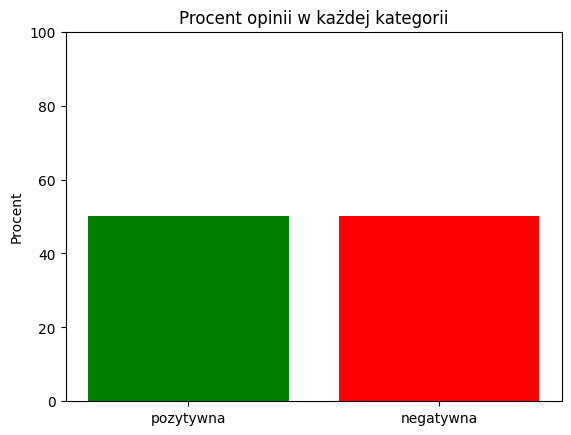


  Opinia 1: Grafika w tej grze jest absolutnie zachwycająca!
 Klasyfikacja: POZYTYWNA
  → pozytywna: 0.6717
  → negatywna: 0.1218

  Opinia 2: Sterowanie jest toporne i frustrujące.
 Klasyfikacja: NEGATYWNA
  → pozytywna: 0.1295
  → negatywna: 0.5889

  Opinia 3: Muzyka idealnie buduje klimat gry.
 Klasyfikacja: POZYTYWNA
  → pozytywna: 0.4873
  → negatywna: -0.0193

  Opinia 4: Zbugowana – co chwilę musiałem restartować.
 Klasyfikacja: NEGATYWNA
  → pozytywna: 0.3146
  → negatywna: 0.4708

  Opinia 5: Zawiodłem się, spodziewałem się czegoś lepszego.
 Klasyfikacja: NEGATYWNA
  → pozytywna: 0.2382
  → negatywna: 0.5355

  Opinia 6: Przeszedłem tylko dlatego, że wydałem kasę.
 Klasyfikacja: NEGATYWNA
  → pozytywna: 0.1703
  → negatywna: 0.3239

  Opinia 7: Jedna z najlepszych gier, jakie kiedykolwiek grałem.
 Klasyfikacja: POZYTYWNA
  → pozytywna: 0.6465
  → negatywna: 0.2699

  Opinia 8: Gra działa płynnie i bez żadnych błędów.
 Klasyfikacja: POZYTYWNA
  → pozytywna: 0.6168
  → negatyw

In [26]:
file_path = "opinie.txt"
results, details = analyze_opinions(file_path)
show_results(results)
show_detailed_results(details)

### 7. Interface do testowania z plikiem (BONUS)

In [27]:
def classify_file_interface(file):
    opinions = load_opinions(file.name)
    results, all_info = analyze_opinions(file.name)

    total = results['pozytywna'] + results['negatywna']
    summary = (
        f" Liczba opinii: {total}\n"
        f" Pozytywne: {results['pozytywna']} ({results['pozytywna'] / total:.1%})\n"
        f" Negatywne: {results['negatywna']} ({results['negatywna'] / total:.1%})\n\n"
    )

    details_text = ""
    for i, (opinia, kategoria, podobienstwa) in enumerate(all_info):
        details_text += f" Opinia {i+1}: {opinia}\n"
        details_text += f" Klasyfikacja: {kategoria.upper()}\n"
        for kat, val in podobienstwa.items():
            details_text += f"→ {kat}: {val:.4f}\n"
        details_text += "\n"

    return summary + details_text

In [28]:
gr.Interface(
    fn=classify_file_interface,
    inputs=gr.File(label="Wgraj plik z opiniami (.txt)"),
    outputs=gr.Textbox(label="Wyniki klasyfikacji", lines=30),
    title="Klasyfikator opinii z pliku",
    description="Wgraj plik tekstowy (.txt)"
).launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://69a6f746c8fd5abdf4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
